# Getting started

How to work with model weights, layers, and activations in this project.

**Before you run anything:** check the kernel in the top-right corner reads
**`Python (research ARM64)`**. The `python3` kernel on this machine is an
emulated x64 build with no PyTorch installed, and picking it produces confusing
`ModuleNotFoundError`s.

Run the next cell first — it verifies the environment and pins model downloads
to `D:/research/models`.

In [1]:
# `research` must be imported before `transformers` / `huggingface_hub`:
# it sets HF_HUB_CACHE, and huggingface_hub reads that once, at import time.
import research
from research import models, paths

import os
import sys

import torch

print("python     :", sys.version.split("(")[0].strip(), sys.version.split("[")[-1].rstrip("]"))
print("torch      :", torch.__version__, "| threads:", torch.get_num_threads())
print("model cache:", os.environ["HF_HUB_CACHE"])
assert "ARM64" in sys.version, "Wrong kernel - pick 'Python (research ARM64)'"

D:\research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python     : 3.13.15 MSC v.1944 64 bit (ARM64)
torch      : 2.9.1+cpu | threads: 8
model cache: D:\research\models


## 1. Load a model

`models.load()` returns a `(model, tokenizer)` pair on the CPU in `float32`.

Mind the memory budget: this machine has **16 GB of unified RAM and no GPU**, so
a full float32 load costs roughly **4 bytes per parameter**. That caps you at
around **1-3 B parameters**. `gpt2` (124 M) is tiny and loads in seconds; a 9 B
model will not fit at any dtype. See section 5 for how to inspect those anyway.

In [2]:
model, tok = models.load("gpt2")

n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} parameters ({n_params * 4 / 1e9:.2f} GB at float32)")
model.config.model_type, model.config.n_layer, model.config.n_embd

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7227.01it/s]

124,439,808 parameters (0.50 GB at float32)


('gpt2', 12, 768)

## 2. See the layers

`models.layer_table()` lists every submodule that owns parameters, with its
class, parameter count, and the shape of each tensor. Modules with no
parameters of their own (activations, dropout) are skipped.

**Tied weights are counted once.** GPT-2 ties `lm_head.weight` to
`transformer.wte.weight` — they are the same tensor. Counting both would report
163 M parameters for a 124 M model, so the tied module is credited 0 parameters
and flagged, with `tied_to` naming the owner. The total therefore reconciles
with `sum(p.numel() for p in model.parameters())`.

In [3]:
import pandas as pd

table = pd.DataFrame(models.layer_table(model))

print(f"{len(table)} parameterised modules")
print(f"layer_table total : {table['params'].sum():,}")
print(f"model total       : {sum(p.numel() for p in model.parameters()):,}")
print("tied:", table.loc[table["tied"], ["name", "tied_to"]].to_dict("records"))

table.head(10)

76 parameterised modules
layer_table total : 124,439,808
model total       : 124,439,808


tied: [{'name': 'lm_head', 'tied_to': 'transformer.wte'}]


,name,class,params,tied,tied_to,shapes
0,transformer.wte,Embedding,38597376,False,NaN,"{'weight': (50257, 768)}"
1,transformer.wpe,Embedding,786432,False,NaN,"{'weight': (1024, 768)}"
2,transformer.h.0.ln_1,LayerNorm,1536,False,NaN,"{'weight': (768,), 'bias': (768,)}"
3,transformer.h.0.attn.c_attn,Conv1D,1771776,False,NaN,"{'weight': (768, 2304), 'bias': (2304,)}"
4,transformer.h.0.attn.c_proj,Conv1D,590592,False,NaN,"{'weight': (768, 768), 'bias': (768,)}"
5,transformer.h.0.ln_2,LayerNorm,1536,False,NaN,"{'weight': (768,), 'bias': (768,)}"
6,transformer.h.0.mlp.c_fc,Conv1D,2362368,False,NaN,"{'weight': (768, 3072), 'bias': (3072,)}"
7,transformer.h.0.mlp.c_proj,Conv1D,2360064,False,NaN,"{'weight': (3072, 768), 'bias': (768,)}"
8,transformer.h.1.ln_1,LayerNorm,1536,False,NaN,"{'weight': (768,), 'bias': (768,)}"
9,transformer.h.1.attn.c_attn,Conv1D,1771776,False,NaN,"{'weight': (768, 2304), 'bias': (2304,)}"


Parameter count by module class — where the weight actually sits:

In [4]:
table.groupby("class")["params"].agg(["count", "sum"]).sort_values("sum", ascending=False)

,count,sum
class,,
Conv1D,48,85017600
Embedding,2,39383808
LayerNorm,25,38400
Linear,1,0


## 3. Read a weight tensor

`models.weight()` takes the dotted module path from the table above and returns
a detached tensor, so you can compute on it without touching autograd.

In [5]:
w = models.weight(model, "transformer.h.0.attn.c_attn.weight")
print(f"shape {tuple(w.shape)}  mean {w.mean():+.5f}  std {w.std():.5f}")

# GPT-2 packs Q, K and V into one matrix - split it back out
q, k, v = w.chunk(3, dim=1)
for name, part in zip("qkv", (q, k, v), strict=True):
    print(f"  {name}: {tuple(part.shape)}  std {part.std():.5f}")

shape (768, 2304)  mean +0.00005  std 0.19962
  q: (768, 768)  std 0.23869
  k: (768, 768)  std 0.24330
  v: (768, 768)  std 0.05812


How weight scale varies with depth — a cheap first look at a real model:

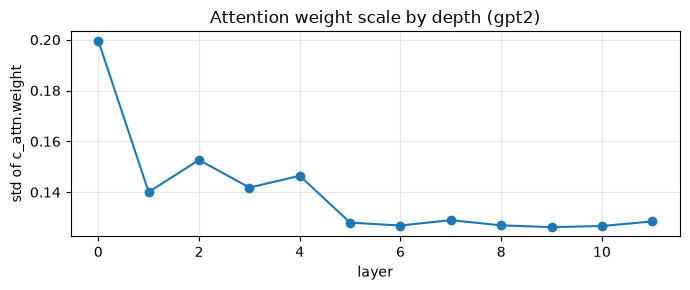

In [6]:
import matplotlib.pyplot as plt

stds = [models.weight(model, f"transformer.h.{i}.attn.c_attn.weight").std().item()
        for i in range(model.config.n_layer)]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(len(stds)), stds, marker="o")
ax.set_xlabel("layer")
ax.set_ylabel("std of c_attn.weight")
ax.set_title("Attention weight scale by depth (gpt2)")
ax.grid(alpha=.3)
plt.tight_layout()

## 4. Capture activations

`models.capture()` is a context manager that registers forward hooks on the
modules you name and collects their outputs.

Always use it rather than calling `register_forward_hook` yourself: it removes
the hooks on exit **even if the body raises**. A leaked hook stays attached to
the model and silently corrupts every later forward pass in the session — one
of the nastier bugs to track down in a long-lived notebook.

Wrap the forward pass in `torch.no_grad()`; nothing here trains, and the
autograd graph would waste the memory that is already the binding constraint.

In [7]:
inputs = tok("The capital of France is", return_tensors="pt")

watch = ["transformer.h.0", "transformer.h.5.attn", "transformer.h.11.mlp", "transformer.ln_f"]

with models.capture(model, watch) as acts:
    with torch.no_grad():
        out = model(**inputs)

for name in watch:
    a = acts[name]
    print(f"{name:<24} {str(tuple(a.shape)):<16} mean {a.mean():+.4f}  std {a.std():.4f}")

print()
print("next token ->", repr(tok.decode(out.logits[0, -1].argmax())))

transformer.h.0          (1, 5, 768)      mean +0.0471  std 2.8246
transformer.h.5.attn     (1, 5, 768)      mean -0.0013  std 0.3110
transformer.h.11.mlp     (1, 5, 768)      mean -0.0288  std 3.6515
transformer.ln_f         (1, 5, 768)      mean +0.2684  std 6.8302

next token -> ' the'


Residual-stream norm growing through the network — the classic view you would
otherwise reach for TransformerLens to get. (TransformerLens does not install on
Windows ARM64; see `docs/arm64-python-stack.md`.)

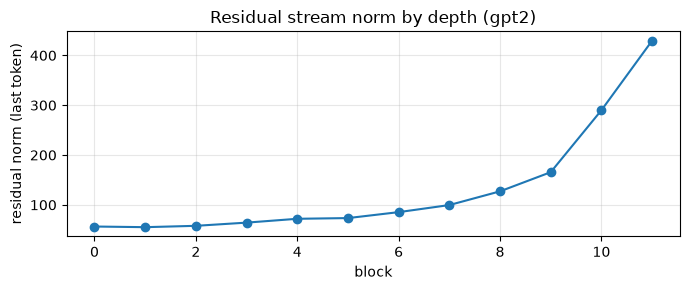

In [8]:
blocks = [f"transformer.h.{i}" for i in range(model.config.n_layer)]

with models.capture(model, blocks) as acts:
    with torch.no_grad():
        model(**inputs)

norms = [acts[b][0, -1].norm().item() for b in blocks]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(norms, marker="o")
ax.set_xlabel("block")
ax.set_ylabel("residual norm (last token)")
ax.set_title("Residual stream norm by depth (gpt2)")
ax.grid(alpha=.3)
plt.tight_layout()

## 5. Inspect models too large to load

`models.raw_tensors()` reads shapes and dtypes straight from the safetensors
header. Nothing is materialised, so this works on files far larger than RAM —
this is how you study a 9 B model on a machine that cannot hold one.

In [9]:
snapshot = next(paths.MODELS.rglob("*.safetensors")).parent
tensors = models.raw_tensors(snapshot)

print(f"{len(tensors)} tensors in {snapshot.name}")
for key in list(tensors)[:5]:
    shape, dtype, shard = tensors[key]
    print(f"  {key:<32} {str(shape):<18} {dtype}")

160 tensors in 607a30d783dfa663caf39e06633721c8d4cfcd7e
  h.0.attn.bias                    (1, 1, 1024, 1024) F32
  h.0.attn.c_attn.bias             (2304,)            F32
  h.0.attn.c_attn.weight           (768, 2304)        F32
  h.0.attn.c_proj.bias             (768,)             F32
  h.0.attn.c_proj.weight           (768, 768)         F32


Pull exactly one tensor into memory when you need the values:

In [10]:
one = models.read_tensor(snapshot / "model.safetensors", "h.0.attn.c_attn.weight")
print(tuple(one.shape), one.dtype)

(768, 2304) torch.float32


### Quantised weights from Ollama

`models.gguf_tensors()` reads the GGUF blobs Ollama already has on disk, which
lets you compare a quantised copy against the original safetensors.

Note this reads the whole file and is slow — an 815 MB blob took over five
minutes. Cache the result rather than re-running the cell.

In [11]:
from collections import Counter

blob = models.ollama_blob("gemma3:1b")
print(f"{blob.name[:24]}...  {blob.stat().st_size / 1e6:.0f} MB")

gguf = models.gguf_tensors(blob)                 # slow - see note above
print(f"{len(gguf)} tensors")
print("quantisation mix:", dict(Counter(t["quant"] for t in gguf)))

sha256-7cd4618c1faf8b723...  815 MB


340 tensors
quantisation mix: {'F32': 157, 'Q8_0': 14, 'Q5_0': 117, 'Q4_K': 39, 'Q6_K': 13}


## House rules

- **Notebooks are the working surface.** Explore here, with prose explaining
  what you are testing and why.
- **Logic that a second notebook needs graduates to `src/research/`** and gets
  a test. If you are copy-pasting a cell between notebooks, it belongs in the
  package.
- **A finding that lives only in a cell is not finished** — write it up in
  `docs/`, with the model id, revision, dtype and seed needed to reproduce it.
- **Seed anything stochastic** (`torch.manual_seed`) and record the seed.
- **Clear outputs before committing**, unless the output *is* the
  documentation (as in this notebook).

Next: copy `notebooks/_template.ipynb` to start your own.